# Insertion-sort vs Counting-sort

# Introduzione
*Insertion-sort* e *Counting-sort* sono due importanti algoritmi di ordinamento. Si differenziano notevolmente per il funzionamento, la complessità e l’efficienza a seconda del tipo e della dimensione del dataset.

**Insertion Sort** è un algoritmo semplice e intuitivo, particolarmente efficace su dataset di piccole dimensioni o su dati già quasi ordinati. Tuttavia, la sua complessità quadratica lo rende poco adatto a dataset di grandi dimensioni o completamente disordinati.

Invece, **Counting Sort** è un algoritmo non comparativo che si basa sulla frequenza degli elementi e sulla loro rappresentazione tramite un array di conteggio. È particolarmente efficiente quando i valori da ordinare sono numeri interi limitati a un certo intervallo, garantendo una complessità lineare rispetto alla dimensione del dataset e al range dei valori.

# Insertion-sort
## Descrizione
*Insertion-sort* costruisce l'array ordinato un elemento alla volta, confrontando ogni elemento con quelli già ordinati e inserendolo nella posizione corretta. È efficiente per piccoli dataset o liste quasi ordinate, ma diventa inefficiente su dataset di grandi dimensioni, con complessità $O(n^2)$
## Implementazione


In [2]:
def insertionSort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i-1
        while j >= 0 and key < arr[j] :
            arr[j+1] = arr [j]
            j -= 1
        arr[j+1] = key
    return arr

## Esempio di utilizzo

In [11]:
arr = [12, 11, 13, 5, 6, 18, 7, 9, 1, 0]
print("Lista ordinata", insertionSort(arr))

Lista ordinata [0, 1, 5, 6, 7, 9, 11, 12, 13, 18]


## Tempo di esecuzione
L'*insertion-sort* ha una complessità temporale di $O(n^2)$ nel caso peggiore, che si verifica quando la lista è ordinata in modo decrescente. In questo scenario, ogni elemento deve essere confrontato con tutti gli altri già ordinati, comportando un numero elevato di confronti e spostamenti. Tuttavia, nel caso migliore, su una lista già ordinata, l'algoritmo ha una complessità di $O(n)$

# Counting-sort
## Descrizione
*Counting-sort* è un algoritmo di ordinamento non basato su confronti, particolarmente efficiente quando si lavora con numeri interi in un intervallo limitato. L'algoritmo conta quante volte ciascun valore compare nell'array di input, e poi ricostruisce l'array ordinato usando queste frequenze. È ideale per dataset in cui i valori da ordinare sono tutti interi non negativi e l'intervallo dei valori non è troppo ampio. L'algoritmo non è stabile e ha una complessità lineare in molti casi pratici, ma utilizza memoria aggiuntiva.
## Implementazione

In [6]:
def countingSort(arr):
    maxVal = max(arr)
    count = [0] * (maxVal + 1)
    for num in arr:
        count[num] += 1
    index = 0
    for i in range(len(count)):
        while count[i] > 0:
            arr[index] = i
            index += 1
            count[i] -= 1
    return arr

## Esempio di utilizzo

In [13]:
arr = [12, 11, 13, 5, 6, 18, 7, 9, 1, 0]
print("Lista ordinata", countingSort(arr))

Lista ordinata [0, 1, 5, 6, 7, 9, 11, 12, 13, 18]


## Tempo di esecuzione
Il *Counting-sort* ha una complessità temporale di $O(n + k)$, dove $n$ è il numero di elementi da ordinare e $k$ è il valore massimo presente nell'array. Questo lo rende molto efficiente quando $k$ non è molto più grande di $n$. Tuttavia, se $k$ è molto grande, l'uso di memoria e il tempo possono crescere rapidamente.

# Test


Test con lista CASUALE:
[Lista Casuale] Numero di elementi: 2000
[Lista Casuale] Numero di elementi: 4000
[Lista Casuale] Numero di elementi: 6000
[Lista Casuale] Numero di elementi: 8000
[Lista Casuale] Numero di elementi: 10000


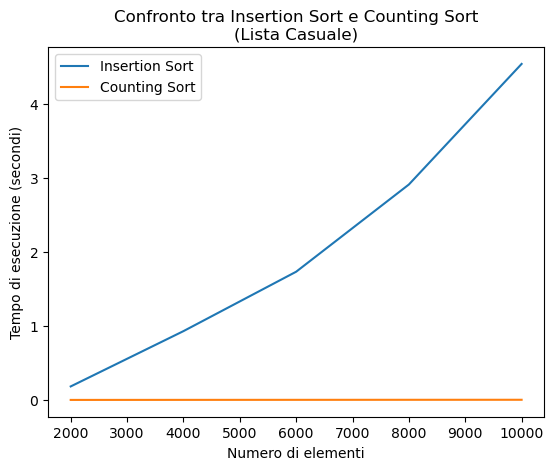


Test con lista ORDINATA:
[Lista Ordinata] Numero di elementi: 2000
[Lista Ordinata] Numero di elementi: 4000
[Lista Ordinata] Numero di elementi: 6000
[Lista Ordinata] Numero di elementi: 8000
[Lista Ordinata] Numero di elementi: 10000


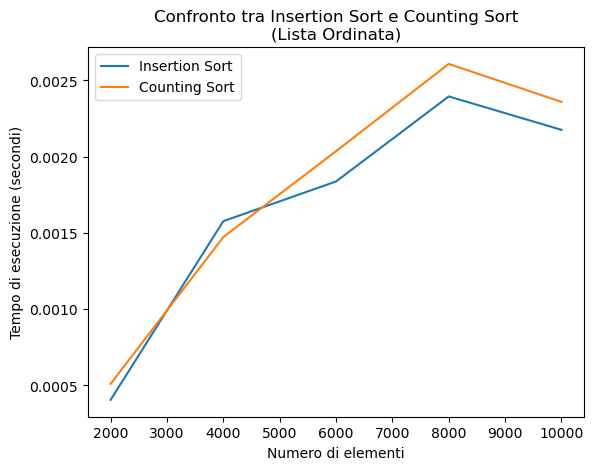


Test con lista ORDINATA DECRESCENTE:
[Lista Ordinata Decrescente] Numero di elementi: 2000
[Lista Ordinata Decrescente] Numero di elementi: 4000
[Lista Ordinata Decrescente] Numero di elementi: 6000
[Lista Ordinata Decrescente] Numero di elementi: 8000
[Lista Ordinata Decrescente] Numero di elementi: 10000


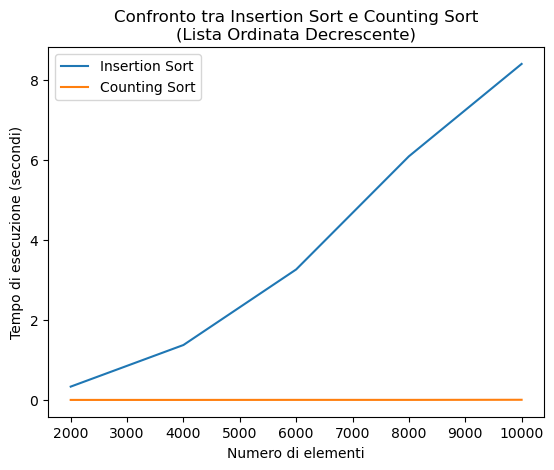

In [10]:
import random
from timeit import default_timer as timer
import matplotlib.pyplot as plt

def listaCasuale(num_elementi, massimo=1000):
    return [random.randint(0, massimo) for _ in range(num_elementi)]

def listaOrdinata(num_elementi, massimo=1000):
    return sorted(listaCasuale(num_elementi, massimo))

def listaOrdinataDecrescente(num_elementi, massimo=1000):
    return sorted(listaCasuale(num_elementi, massimo), reverse=True)

def test(nome_lista, alg_lista, num_elementi, iterazioni):
    dimensioni_lista = []
    insertion_sort_t = []
    counting_sort_t = []

    lista_max = alg_lista(num_elementi * iterazioni)

    for i in range(iterazioni):
        n = num_elementi * (i + 1)
        dimensioni_lista.append(n)
        print(f"[{nome_lista}] Numero di elementi: {n}")

        lista = lista_max[:n]

        copia_lista = lista.copy()
        start = timer()
        insertionSort(copia_lista)
        stop = timer()
        insertion_sort_t.append(stop - start)

        copia_lista = lista.copy()
        start = timer()
        countingSort(copia_lista)
        stop = timer()
        counting_sort_t.append(stop - start)

    plt.plot(dimensioni_lista, insertion_sort_t, label='Insertion Sort')
    plt.plot(dimensioni_lista, counting_sort_t, label='Counting Sort')
    plt.xlabel('Numero di elementi')
    plt.ylabel('Tempo di esecuzione (secondi)')
    plt.title(f'Confronto tra Insertion Sort e Counting Sort\n({nome_lista})')
    plt.legend()
    plt.show()

def main():
    num_elementi = 2000
    iterazioni = 20

    print('\nTest con lista CASUALE:')
    test("Lista Casuale", listaCasuale, num_elementi, iterazioni)

    print('\nTest con lista ORDINATA:')
    test("Lista Ordinata", listaOrdinata, num_elementi, iterazioni)

    print('\nTest con lista ORDINATA DECRESCENTE:')
    test("Lista Ordinata Decrescente", listaOrdinataDecrescente, num_elementi, iterazioni)

main()


# Confronto dei grafici
Nel primo grafico, lista casuale, si nota che il tempo di esecuzione di *Insertion-sort* cresce in maniera più rapida rispetto a quello di *Counting-sort*. Questo è atteso perché il primo ha una complessità $O(n^2)$ nei casi medi e peggiori mentre il secondo ha complessità $O(n+k)$, dove $k$ è il valore massimo possibile degli elementi. In questo caso k = 1000, quindi praticamente una costante. Concludiamo che *Counting-sort* è nettamente più efficiente su dati casuali.

Nel secondo grafico, lista ordinata crescente, i tempi di *Insertion-sort* migliorano rispetto al caso casuale. Questo perché nel caso già ordinato, l'algoritmo effettua pochissimi spostamenti, avvicinandosi alla sua complessità ottimale $O(n)$. *Counting-sort* invece mantiene tempi simili a prima, perché non sfrutta alcun ordine iniziale dei dati. Concludiamo che *Insertion-sort* è comparabile (e per certi input migliore) di *Counting-sort* su lista già ordinata.

Nel terzo grafico, lista ordinata decrescente, troviamo una situazione simile alla prima in cui *Insertion-sort* impiega tempi molto alti, e cresce quadraticamente. Questo perché ogni elemento deve essere spostato fino in fondo, quindi è il caso peggiore possibile. Mentre il *Counting-sort* resta sempre molto più veloce.

# Osservazioni finali
**Counting-sort** è estremamente veloce, ma funziona solo con numeri interi non negativi in un range limitato.

**Insertion-sort** è semplice e performante solo in casi molto favorevoli(liste già ordinate o quasi), ma inefficiente su liste grandi e disordinate.
